# Distribución del inventario de eventos por tipo de Slope Unit

**Tesis MSc — Oscar I. Sánchez P.**

Este cuaderno responde a una pregunta clave para la **Parte 2**: ¿es viable derivar umbrales de lluvia separados por tipo de Slope Unit (`su_type`)?

La viabilidad depende de tener **suficientes eventos por tipo** para ajustar un modelo robusto. La regla práctica habitual es:

- **≥ 30 eventos por tipo**: análisis robusto, modelo bien identificado.
- **10–30 eventos**: análisis posible pero frágil, intervalos de credibilidad amplios.
- **< 10 eventos**: insuficiente para un modelo independiente; conviene fusionar tipos o usar un modelo global con interacción.

Aquí inspeccionamos la capa `su_susceptibles_con_inventario.gpkg` (resultado del cuaderno previo) y producimos:

1. Tabla resumen de eventos y SUs por tipo de SU.
2. Gráfico de barras con conteo de eventos por tipo.
3. Gráfico de la tasa de eventos (eventos / SU) por tipo.
4. Distribución de tipos de movimiento dentro de cada tipo de SU.
5. Mapa coroplético: SUs susceptibles coloreadas por tipo, con eventos superpuestos.
6. Recomendación operativa para el diseño de la Parte 2.

## 1. Importación de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 110,
})

## 2. Carga de la capa con SUs susceptibles e inventario asociado

Esta capa fue producida por el cuaderno `asociar_eventos_a_su_susceptibles.ipynb`. Recordemos su estructura:

- Una fila por SU si la SU no tiene eventos, o una fila por (SU, evento) si tiene eventos.
- Columna `mm_si`: 1 si la fila representa un evento, 0 si no.
- Columna `su_type`: tipo morfométrico de la SU (clusters de slope, curvatura, aspecto).

In [2]:
PATH_IN = '/home/oisanchezp/Thesis/data/processed/su_susceptibles_con_inventario.gpkg'

gdf = gpd.read_file(PATH_IN)

print(f'Filas totales      : {len(gdf):,}')
print(f'CRS                : {gdf.crs}')
print(f'Columnas (n={len(gdf.columns)}):')
for c in gdf.columns:
    print(f'  - {c}')

# Verificaciones mínimas
assert 'mm_si' in gdf.columns, 'Falta la columna mm_si'
assert 'su_type' in gdf.columns, 'Falta la columna su_type'

# Identificador único de SU
id_col = 'su_id' if 'su_id' in gdf.columns else 'Id'
print(f'\nIdentificador de SU usado: {id_col}')

Filas totales      : 55,332
CRS                : EPSG:32618
Columnas (n=53):
  - Id
  - gridcode
  - Shape_Leng
  - Shape_Area
  - slope_mean
  - curva_mean
  - acos_mean
  - asin_mean
  - aspect_mea
  - area
  - su_type
  - su_id
  - Codigo
  - Unidad_geo
  - Granulomet
  - Espesor_m
  - Gamma_kNm3
  - C_kPa
  - Phi
  - cobertura_cat
  - cobertura
  - n_mm
  - si_no
  - suelos
  - zona_lluvia
  - geologia
  - tipo_su
  - zona
  - log_area
  - mm
  - p_structural_given_zero
  - susceptible
  - mu_post
  - mu_post_km2
  - mu_q025
  - mu_q975
  - mu_sd
  - bym_mean
  - bym_sd
  - p_estructural
  - p_susceptible
  - clase_susc
  - incluir_parte2
  - fecha_hora_evento
  - latitud
  - longitud
  - tipo_movimiento
  - municipio
  - corregimiento
  - vereda_barrio
  - Codigo_estacion
  - mm_si
  - geometry

Identificador de SU usado: su_id


## 3. Tabla resumen: eventos y SUs por tipo

Distinguimos dos cantidades:
- **n_eventos**: filas con `mm_si = 1` (cada deslizamiento del inventario aporta una fila).
- **n_SUs_susceptibles**: SUs únicas en el subconjunto.
- **n_SUs_con_evento**: SUs únicas que tuvieron al menos un evento.
- **tasa_eventos_por_SU**: n_eventos / n_SUs_susceptibles.

In [3]:
# Eventos por tipo (filas con mm_si == 1)
eventos_por_tipo = (gdf.loc[gdf['mm_si'] == 1]
                       .groupby('su_type')
                       .size()
                       .rename('n_eventos'))

# SUs únicas por tipo (todas, no duplicadas por evento)
sus_por_tipo = (gdf.drop_duplicates(subset=id_col)
                   .groupby('su_type')
                   .size()
                   .rename('n_SUs_susceptibles'))

# SUs con al menos un evento por tipo
sus_con_evento = (gdf.loc[gdf['mm_si'] == 1]
                     .drop_duplicates(subset=id_col)
                     .groupby('su_type')
                     .size()
                     .rename('n_SUs_con_evento'))

# Combinar en una tabla
resumen = (pd.concat([sus_por_tipo, sus_con_evento, eventos_por_tipo], axis=1)
             .fillna(0)
             .astype(int))

# Métricas derivadas
resumen['tasa_eventos_por_SU']  = (resumen['n_eventos']
                                    / resumen['n_SUs_susceptibles']).round(4)
resumen['pct_SUs_con_evento']   = (100 * resumen['n_SUs_con_evento']
                                    / resumen['n_SUs_susceptibles']).round(2)

# Etiqueta de viabilidad para la Parte 2
def viabilidad(n):
    if n >= 30:
        return 'Robusto'
    elif n >= 10:
        return 'Frágil'
    else:
        return 'Insuficiente'

resumen['viabilidad_modelo_separado'] = resumen['n_eventos'].apply(viabilidad)

# Totales
total_row = pd.DataFrame({
    'n_SUs_susceptibles': [resumen['n_SUs_susceptibles'].sum()],
    'n_SUs_con_evento':   [resumen['n_SUs_con_evento'].sum()],
    'n_eventos':          [resumen['n_eventos'].sum()],
    'tasa_eventos_por_SU': [round(resumen['n_eventos'].sum()
                                  / resumen['n_SUs_susceptibles'].sum(), 4)],
    'pct_SUs_con_evento': [round(100 * resumen['n_SUs_con_evento'].sum()
                                  / resumen['n_SUs_susceptibles'].sum(), 2)],
    'viabilidad_modelo_separado': ['—'],
}, index=['TOTAL'])

resumen_full = pd.concat([resumen, total_row])

print('Resumen por tipo de Slope Unit:\n')
print(resumen_full.to_string())

# Guardar como CSV para incluir en la tesis
resumen_full.to_csv('resumen_eventos_por_tipo_su.csv')
print('\n✓ Tabla guardada: resumen_eventos_por_tipo_su.csv')

Resumen por tipo de Slope Unit:

       n_SUs_susceptibles  n_SUs_con_evento  n_eventos  tasa_eventos_por_SU  pct_SUs_con_evento viabilidad_modelo_separado
1.0                 10419                77         91               0.0087                0.74                    Robusto
2.0                 28945               217        265               0.0092                0.75                    Robusto
3.0                  5853                17         24               0.0041                0.29                     Frágil
4.0                 10025                78         99               0.0099                0.78                    Robusto
TOTAL               55242               389        479               0.0087                0.70                          —

✓ Tabla guardada: resumen_eventos_por_tipo_su.csv


## 4. Gráfico de barras: número de eventos por tipo de SU

Es el dato más directo: ¿cuántos deslizamientos del inventario están asociados a cada tipo? Las líneas de referencia marcan los umbrales de viabilidad (10 y 30 eventos).

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


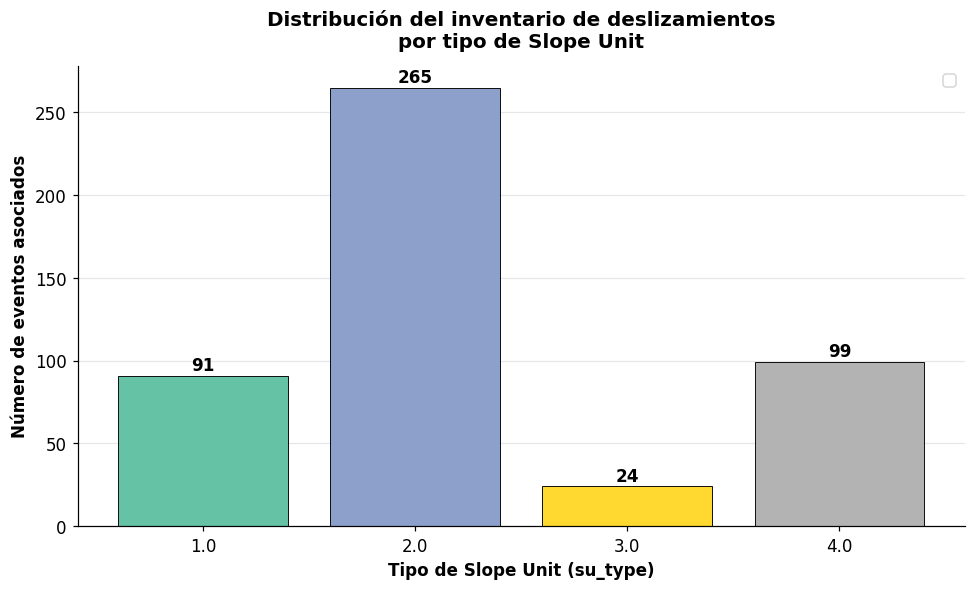

In [4]:
# Paleta consistente para los tipos de SU
tipos = sorted(resumen.index.tolist())
paleta = plt.cm.Set2(np.linspace(0, 1, len(tipos)))
color_map = dict(zip(tipos, paleta))

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    [str(t) for t in resumen.index],
    resumen['n_eventos'],
    color=[color_map[t] for t in resumen.index],
    edgecolor='black', linewidth=0.6
)

# Etiquetas numéricas sobre cada barra
for bar, n in zip(bars, resumen['n_eventos']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{int(n)}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

# Líneas de referencia para viabilidad
# ax.axhline(30, color='#2ca02c', linestyle='--', linewidth=1.2,
#            label='Robusto (≥ 30)')
# ax.axhline(10, color='#d62728', linestyle='--', linewidth=1.2,
#            label='Mínimo viable (≥ 10)')

ax.set_xlabel('Tipo de Slope Unit (su_type)', fontweight='bold')
ax.set_ylabel('Número de eventos asociados', fontweight='bold')
ax.set_title('Distribución del inventario de deslizamientos\npor tipo de Slope Unit',
             pad=12)
ax.legend(loc='upper right', frameon=True)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

plt.tight_layout()
#plt.savefig('eventos_por_tipo_su.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Distribución de área por tipo de SU y densidad de eventos por km²

Aquí miramos tres normalizaciones complementarias al conteo bruto de eventos:

1. **Área total (km²) que abarca cada tipo de SU.** Indica la huella espacial de cada cluster en el Valle.
2. **Porcentaje del área total** ocupado por cada tipo. Útil para entender si un tipo es minoritario o dominante en el dominio.
3. **Eventos por km² (densidad).** Es la medida más justa de propensión: un tipo con muchos eventos pero también mucha área puede ser menos propenso por unidad de territorio que un tipo con menos eventos pero pequeño en huella.

Área y densidad de eventos por tipo de SU:

         n_SUs_susceptibles  n_eventos    area_km2  pct_area_total  eventos_por_km2
su_type                                                                            
1.0                   10419         91  172.868931           19.30             0.53
2.0                   28945        265  511.376346           57.08             0.52
3.0                    5853         24   47.613842            5.31             0.50
4.0                   10025         99  163.981910           18.30             0.60


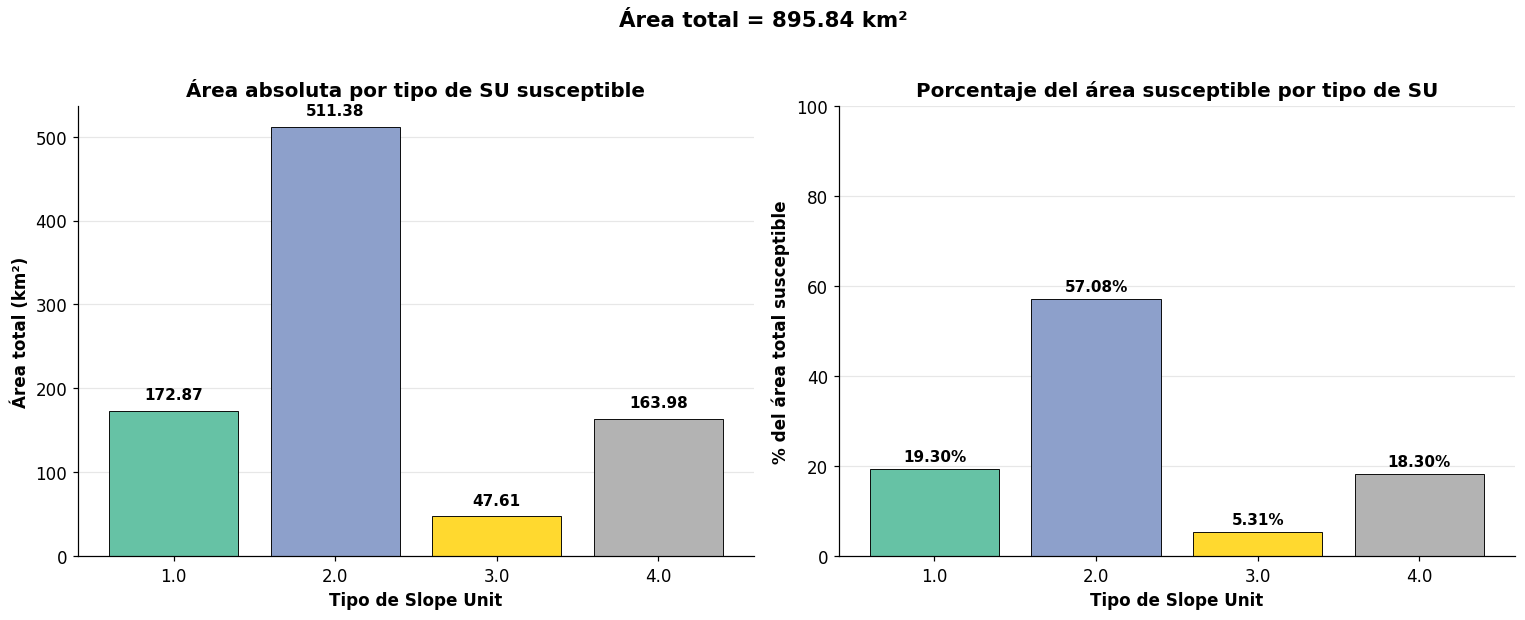

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


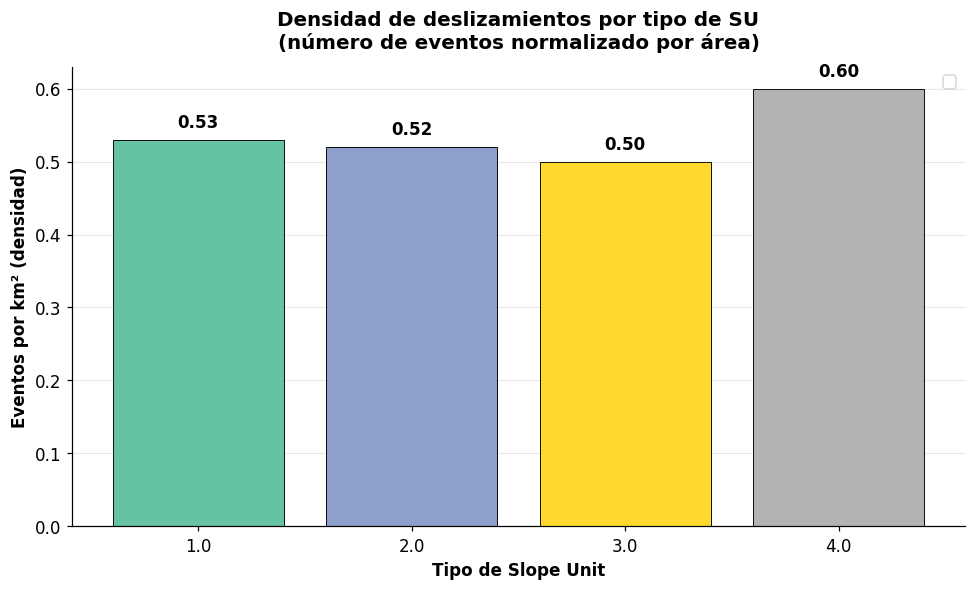

In [5]:
# ---- Cálculo del área por tipo de SU ----
# Usamos las SU únicas (sin duplicar por evento) para no inflar el área
sus_unicas_calc = gdf.drop_duplicates(subset=id_col).copy()

# 'area' debería existir como atributo (en km²); si no, la calculamos desde la geometría
if 'area' in sus_unicas_calc.columns:
    sus_unicas_calc['area_km2'] = sus_unicas_calc['area'].astype(float)
else:
    # geometry_area en m² → dividir por 1e6 para km²
    sus_unicas_calc['area_km2'] = sus_unicas_calc.geometry.area / 1e6

area_por_tipo = (sus_unicas_calc.groupby('su_type')['area_km2']
                                  .sum()
                                  .reindex(resumen.index))
area_total = area_por_tipo.sum()

# Adjuntar al resumen para mantener consistencia
resumen['area_km2']            = area_por_tipo
resumen['pct_area_total']      = (100 * resumen['area_km2'] / area_total).round(2)
resumen['eventos_por_km2']     = (resumen['n_eventos']
                                   / resumen['area_km2']).round(2)

print('Área y densidad de eventos por tipo de SU:\n')
print(resumen[['n_SUs_susceptibles', 'n_eventos',
               'area_km2', 'pct_area_total', 'eventos_por_km2']]
      .to_string())

# =====================================================================
# FIGURA 1 — Área absoluta y porcentual por tipo
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Área total en km²
ax = axes[0]
bars = ax.bar(
    [str(t) for t in resumen.index],
    resumen['area_km2'],
    color=[color_map[t] for t in resumen.index],
    edgecolor='black', linewidth=0.6,
)
for bar, v in zip(bars, resumen['area_km2']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + resumen['area_km2'].max() * 0.02,
            f'{v:.2f}', ha='center', va='bottom',
            fontweight='bold', fontsize=10)
ax.set_xlabel('Tipo de Slope Unit', fontweight='bold')
ax.set_ylabel('Área total (km²)', fontweight='bold')
ax.set_title('Área absoluta por tipo de SU susceptible')
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
for s in ['top', 'right']: ax.spines[s].set_visible(False)

# (b) Porcentaje del área total
ax = axes[1]
bars = ax.bar(
    [str(t) for t in resumen.index],
    resumen['pct_area_total'],
    color=[color_map[t] for t in resumen.index],
    edgecolor='black', linewidth=0.6,
)
for bar, v in zip(bars, resumen['pct_area_total']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + resumen['pct_area_total'].max() * 0.02,
            f'{v:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)
ax.set_xlabel('Tipo de Slope Unit', fontweight='bold')
ax.set_ylabel('% del área total susceptible', fontweight='bold')
ax.set_title('Porcentaje del área susceptible por tipo de SU')
ax.set_ylim(0, max(100, resumen['pct_area_total'].max() * 1.15))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
for s in ['top', 'right']: ax.spines[s].set_visible(False)

plt.suptitle(f'Área total = {area_total:.2f} km²',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('area_por_tipo_su.png', dpi=200, bbox_inches='tight')
plt.show()

# =====================================================================
# FIGURA 2 — Densidad de eventos (eventos/km²) por tipo
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    [str(t) for t in resumen.index],
    resumen['eventos_por_km2'],
    color=[color_map[t] for t in resumen.index],
    edgecolor='black', linewidth=0.6,
)
for bar, v in zip(bars, resumen['eventos_por_km2']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + resumen['eventos_por_km2'].max() * 0.02,
            f'{v:.2f}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

# Línea de referencia: densidad promedio global
densidad_global = resumen['n_eventos'].sum() / area_total
# ax.axhline(densidad_global, color='gray', linestyle='--', linewidth=1.2,
#            label=f'Densidad global = {densidad_global:.2f} eventos/km²')

ax.set_xlabel('Tipo de Slope Unit', fontweight='bold')
ax.set_ylabel('Eventos por km² (densidad)', fontweight='bold')
ax.set_title('Densidad de deslizamientos por tipo de SU\n'
             '(número de eventos normalizado por área)', pad=12)
ax.legend(loc='upper right', frameon=True)
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
for s in ['top', 'right']: ax.spines[s].set_visible(False)

plt.tight_layout()
#plt.savefig('densidad_eventos_por_tipo_su.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Distribución de tipos de movimiento dentro de cada tipo de SU

¿Hay tipos de SU que concentran un tipo específico de movimiento (deslizamiento, flujo, caída)? Esto puede ser relevante para el diseño operativo: tipos con dominancia de flujos requieren umbrales distintos de tipos con dominancia de deslizamientos rotacionales.

Eventos por tipo de SU × tipo de movimiento:

tipo_movimiento  Caida de rocas  Complejo  Deslizamiento  Flujo  Otro  Traslacional
su_type                                                                            
1.0                           0         0             62     26     2             0
2.0                           3         4            176     62    14             2
3.0                           1         1             16      6     0             0
4.0                           4         0             81     10     3             0


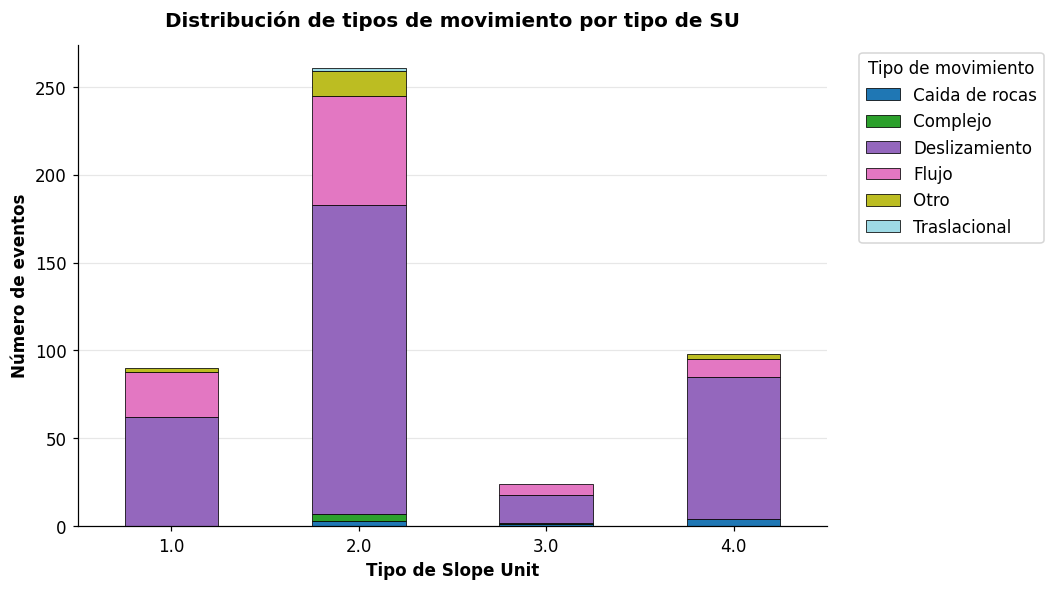

In [6]:
if 'tipo_movimiento' in gdf.columns:
    cruce = (gdf.loc[gdf['mm_si'] == 1]
                .groupby(['su_type', 'tipo_movimiento'])
                .size()
                .unstack(fill_value=0))

    print('Eventos por tipo de SU × tipo de movimiento:\n')
    print(cruce.to_string())

    # Gráfico de barras apiladas
    fig, ax = plt.subplots(figsize=(10, 5.5))
    cruce.plot(kind='bar', stacked=True, ax=ax,
                colormap='tab20', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Tipo de Slope Unit', fontweight='bold')
    ax.set_ylabel('Número de eventos', fontweight='bold')
    ax.set_title('Distribución de tipos de movimiento por tipo de SU', pad=12)
    ax.legend(title='Tipo de movimiento', loc='upper right',
               bbox_to_anchor=(1.30, 1), frameon=True)
    ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    plt.xticks(rotation=0)
    plt.tight_layout()
    #plt.savefig('movimientos_por_tipo_su.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('La columna `tipo_movimiento` no está en el GeoPackage; se omite el cruce.')

## 7. Mapa coroplético: SUs por tipo + eventos

Mostramos las SUs susceptibles coloreadas por su tipo morfométrico, con los eventos del inventario superpuestos como puntos. Esto permite ver la **distribución espacial** de cada tipo en el Valle y verificar visualmente la concentración de eventos.

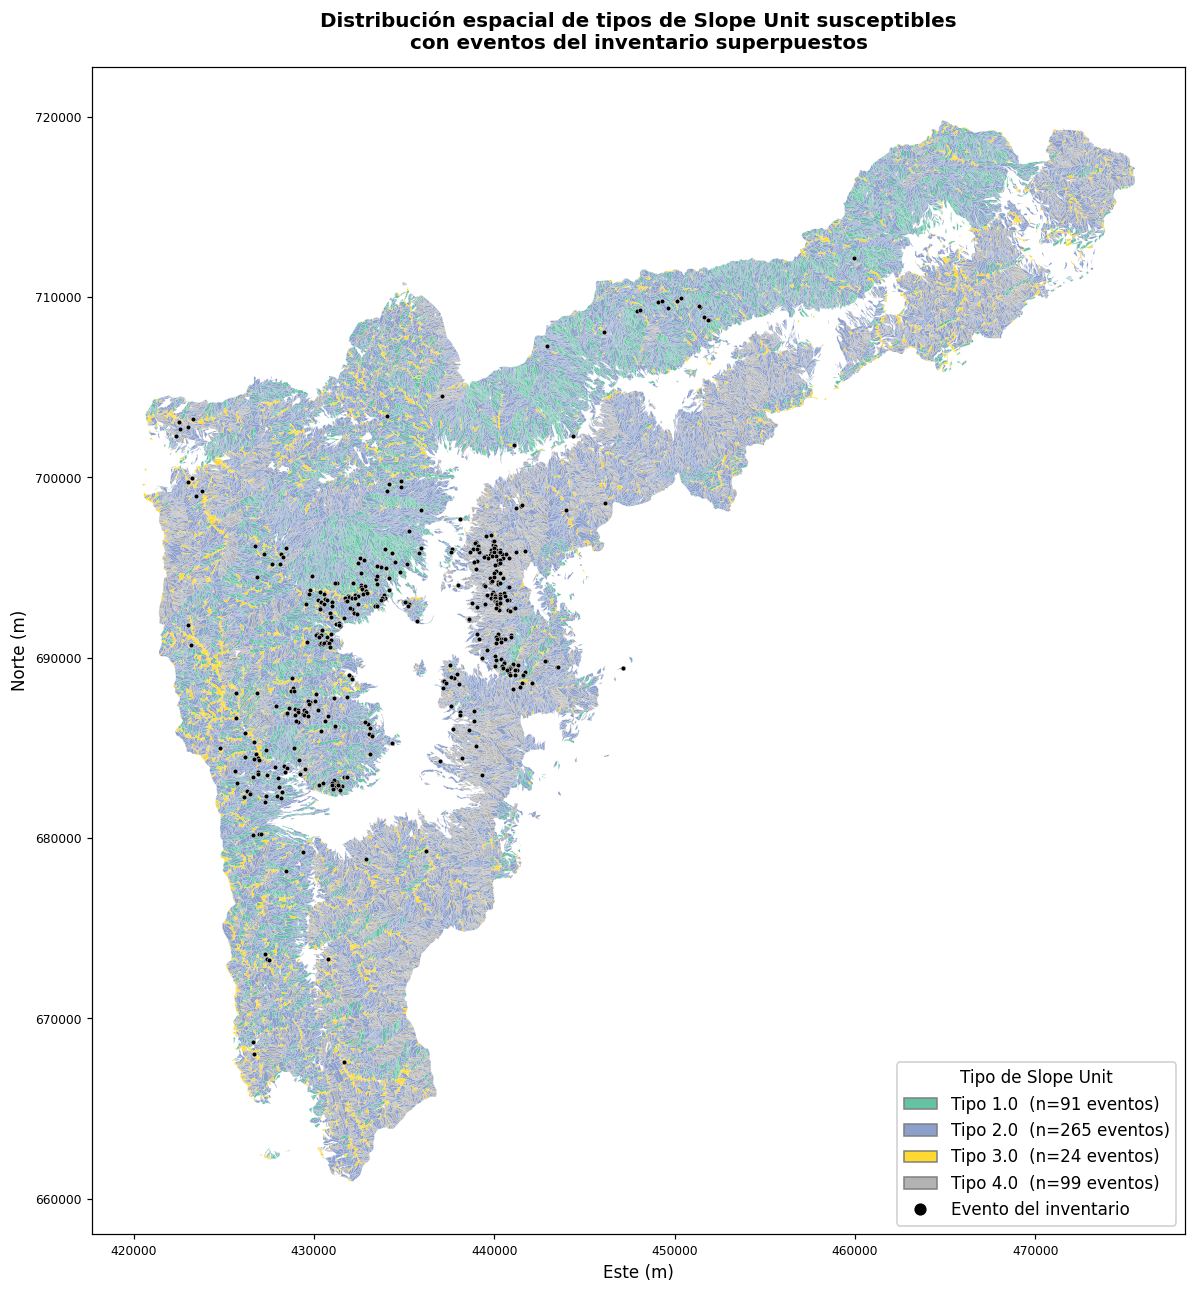

In [7]:
# Capa de SUs únicas (sin duplicar por evento)
su_unicas = (gdf.drop_duplicates(subset=id_col)
                [[id_col, 'su_type', 'geometry']]
                .reset_index(drop=True))
su_unicas = gpd.GeoDataFrame(su_unicas, geometry='geometry', crs=gdf.crs)

# Eventos: una fila por evento (filas con mm_si == 1)
# Reconstruir geometría puntual a partir de lat/lon
eventos_df = gdf.loc[gdf['mm_si'] == 1].copy()
if {'latitud', 'longitud'}.issubset(eventos_df.columns):
    eventos_pts = gpd.GeoDataFrame(
        eventos_df,
        geometry=gpd.points_from_xy(eventos_df['longitud'],
                                     eventos_df['latitud']),
        crs='EPSG:4326'
    ).to_crs(gdf.crs)
else:
    eventos_pts = None

fig, ax = plt.subplots(figsize=(11, 12))

# SUs coloreadas por tipo
for t in tipos:
    sub = su_unicas[su_unicas['su_type'] == t]
    if len(sub):
        sub.plot(ax=ax, color=color_map[t], edgecolor='white',
                  linewidth=0.05, label=f'Tipo {t}')

# Eventos del inventario
if eventos_pts is not None and len(eventos_pts):
    eventos_pts.plot(ax=ax, color='black', markersize=10, marker='o',
                      edgecolor='white', linewidth=0.3)

# Leyenda con cuadros de tipo + punto de evento
handles = [mpatches.Patch(facecolor=color_map[t], edgecolor='gray',
                            label=f'Tipo {t}  (n={resumen.loc[t, "n_eventos"]} eventos)')
           for t in tipos]
if eventos_pts is not None and len(eventos_pts):
    handles.append(Line2D([], [], marker='o', color='w',
                          markerfacecolor='black', markeredgecolor='white',
                          markersize=9, label='Evento del inventario'))

ax.legend(handles=handles, loc='lower right', frameon=True,
          framealpha=0.95, title='Tipo de Slope Unit',
          title_fontsize=11)

ax.set_aspect('equal')
ax.set_title('Distribución espacial de tipos de Slope Unit susceptibles\n'
             'con eventos del inventario superpuestos',
             pad=12)
ax.set_xlabel(f'Este (m)')
ax.set_ylabel(f'Norte (m)')
ax.ticklabel_format(style='plain', useOffset=False)
ax.tick_params(labelsize=8)
#for s in ['top', 'right']: ax.spines[s].set_visible(False)

plt.tight_layout()
#plt.savefig('mapa_tipos_su_con_eventos.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Mapa por facetas: un panel por tipo de SU

Versión alternativa que separa cada tipo en un panel independiente, útil para ver la geometría espacial de cada cluster por separado.

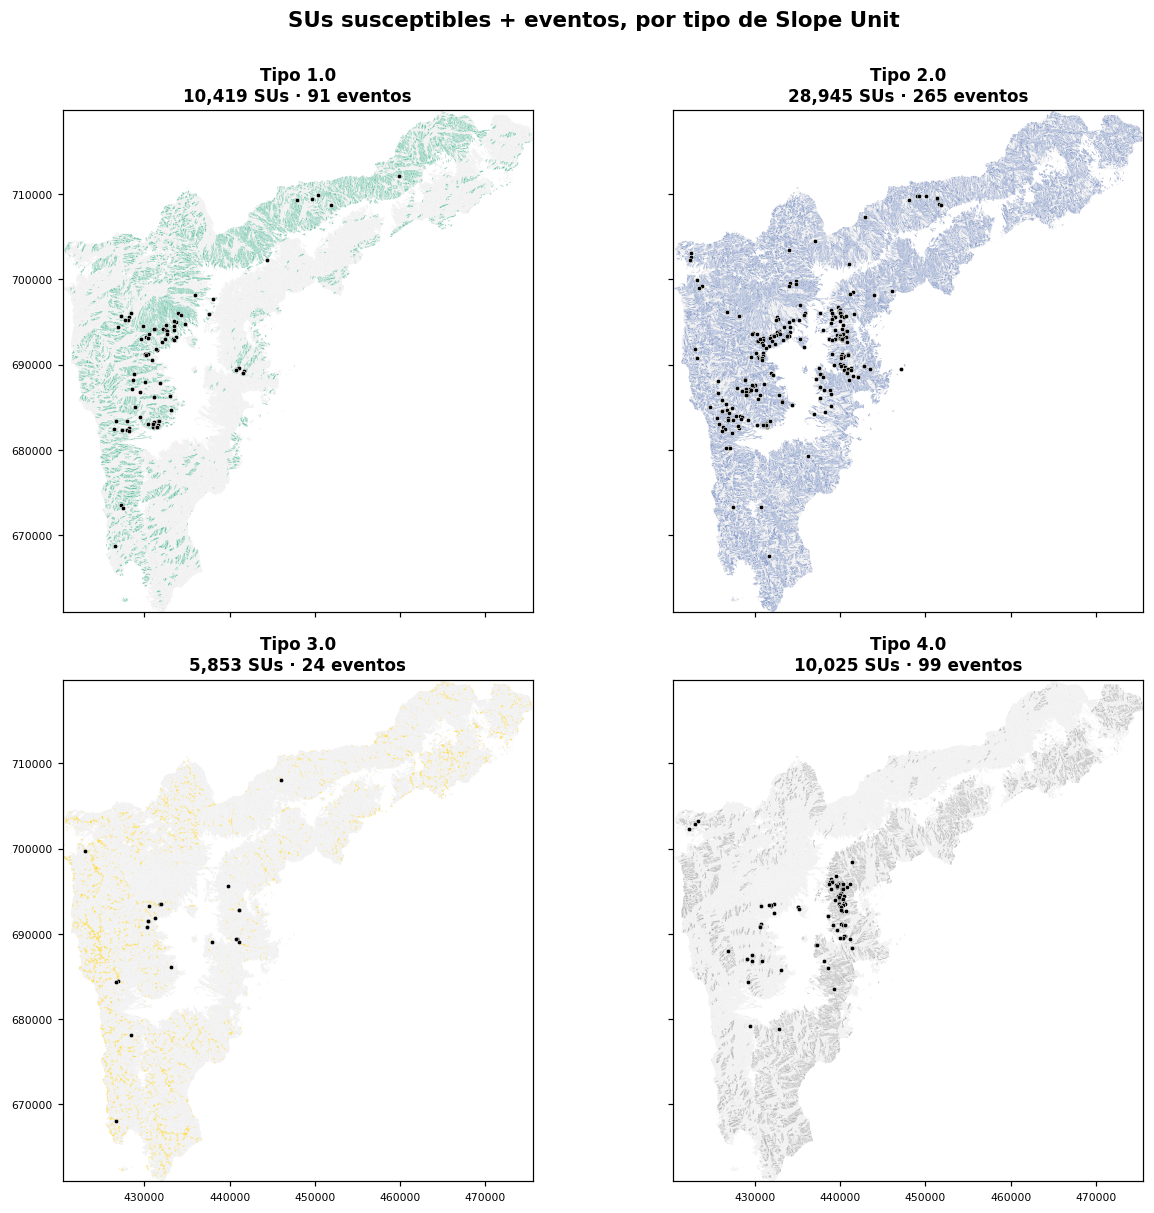

In [9]:
n_tipos = len(tipos)
ncols = 2
nrows = int(np.ceil(n_tipos / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5.5 * nrows),
                          sharex=True, sharey=True)
axes = np.array(axes).flatten()

minx, miny, maxx, maxy = su_unicas.total_bounds

for i, t in enumerate(tipos):
    ax = axes[i]

    # Fondo: todas las SUs susceptibles en gris claro
    su_unicas.plot(ax=ax, color='#eeeeee', edgecolor='white',
                    linewidth=0.05)

    # SUs del tipo en cuestión, en color
    sub = su_unicas[su_unicas['su_type'] == t]
    sub.plot(ax=ax, color=color_map[t], edgecolor='white', linewidth=0.05)

    # Eventos asociados a este tipo
    if eventos_pts is not None and 'su_type' in eventos_pts.columns:
        ev_t = eventos_pts[eventos_pts['su_type'] == t]
        if len(ev_t):
            ev_t.plot(ax=ax, color='black', markersize=8,
                       marker='o', edgecolor='white', linewidth=0.3)

    n_ev = int(resumen.loc[t, 'n_eventos'])
    n_sus = int(resumen.loc[t, 'n_SUs_susceptibles'])
    ax.set_title(f'Tipo {t}\n{n_sus:,} SUs · {n_ev} eventos',
                  fontsize=11)
    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
    ax.ticklabel_format(style='plain', useOffset=False)

# Apagar ejes sobrantes (si ncols * nrows > n_tipos)
for j in range(n_tipos, len(axes)):
    axes[j].axis('off')

plt.suptitle('SUs susceptibles + eventos, por tipo de Slope Unit',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
#plt.savefig('mapa_facetas_tipos_su.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Recomendación operativa para el diseño de la Parte 2

In [ ]:
print('=' * 70)
print('RECOMENDACIÓN PARA EL DISEÑO DE LA PARTE 2')
print('=' * 70)

tipos_robustos      = resumen[resumen['n_eventos'] >= 30].index.tolist()
tipos_fragiles      = resumen[(resumen['n_eventos'] >= 10) &
                                (resumen['n_eventos'] < 30)].index.tolist()
tipos_insuficientes = resumen[resumen['n_eventos'] < 10].index.tolist()

print(f'\nTipos con muestra ROBUSTA (≥ 30 eventos)    : {tipos_robustos}')
print(f'Tipos con muestra FRÁGIL (10–29 eventos)    : {tipos_fragiles}')
print(f'Tipos INSUFICIENTES (< 10 eventos)          : {tipos_insuficientes}')

print('\n' + '-' * 70)
print('Estrategia sugerida según los resultados:')
print('-' * 70)

if len(tipos_insuficientes) == 0 and len(tipos_fragiles) == 0:
    print(
        '\n✓ TODOS los tipos tienen muestra robusta. Puedes ajustar un modelo\n'
        '  separado por cada tipo de SU sin problema. Esta es la opción ideal:\n'
        '  estratificación completa por tipo, umbrales de lluvia específicos\n'
        '  por cada uno.'
    )
elif len(tipos_insuficientes) == 0:
    print(
        f'\n• {len(tipos_robustos)} tipos son robustos: modelos separados.\n'
        f'• {len(tipos_fragiles)} tipos son frágiles: ajustar modelos pero\n'
        '  reportar incertidumbre amplia.\n'
        '  Alternativa: usar un MODELO GLOBAL con interacción tipo_su × lluvia,\n'
        '  que comparte información entre tipos y estabiliza estimaciones para\n'
        '  los grupos pequeños.'
    )
else:
    print(
        f'\n⚠ {len(tipos_insuficientes)} tipo(s) con muestra insuficiente.\n'
        '  Opciones:\n'
        '   1) Fusionar el tipo insuficiente con el más afín morfométricamente.\n'
        '   2) Usar un MODELO GLOBAL con interacción tipo_su × lluvia.\n'
        '   3) Excluir el tipo insuficiente del análisis de umbrales y\n'
        '      reportarlo como limitación.'
    )

print('\n' + '=' * 70)
print('TOTAL eventos disponibles para Parte 2 :',
      f'{int(resumen["n_eventos"].sum())}')
print('TOTAL SUs susceptibles                 :',
      f'{int(resumen["n_SUs_susceptibles"].sum()):,}')
print('Razón eventos / SUs                    :',
      f'{resumen["n_eventos"].sum() / resumen["n_SUs_susceptibles"].sum():.5f}')
print('=' * 70)

---

**Archivos generados:**
- `resumen_eventos_por_tipo_su.csv` — tabla resumen con métricas por tipo.
- `eventos_por_tipo_su.png` — barras con conteo de eventos.
- `tasa_eventos_por_tipo.png` — tasas y cobertura por tipo.
- `movimientos_por_tipo_su.png` — distribución de tipos de movimiento.
- `mapa_tipos_su_con_eventos.png` — mapa coroplético global.
- `mapa_facetas_tipos_su.png` — mapa con paneles por tipo.

**Próximos pasos para la Parte 2:**

1. Decidir, con base en la recomendación de la celda anterior, si se ajusta un modelo por tipo o un modelo global con interacción.
2. Construir el panel SU-día uniendo cada SU susceptible con su lluvia diaria (1d y 33d) y la fase ENSO.
3. Calibrar los umbrales operativos (con análisis de sensibilidad y criterios complementarios).